In [5]:
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Student_Performance.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "nikhil7280/student-performance-multiple-linear-regression",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_26961/3871745319.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'student-performance-multiple-linear-regression' dataset.
First 5 records:    Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  


In [7]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [9]:
df.isna().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [10]:
df.dtypes

,0
Hours Studied,int64
Previous Scores,int64
Extracurricular Activities,object
Sleep Hours,int64
Sample Question Papers Practiced,int64
Performance Index,float64


In [11]:
#One hot encoding
df_encoded = pd.get_dummies(
    df, 
    columns=['Extracurricular Activities'],
    drop_first=True
)

In [12]:
df=df_encoded.astype(int)

In [13]:
df.dtypes

,0
Hours Studied,int64
Previous Scores,int64
Sleep Hours,int64
Sample Question Papers Practiced,int64
Performance Index,int64
Extracurricular Activities_Yes,int64


In [14]:
df.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_Yes
0,7,99,9,1,91,1
1,4,82,4,2,65,0
2,8,51,7,2,45,1
3,5,52,5,2,36,1
4,7,75,8,5,66,0


# Feature Selection

## Lasso

In [15]:
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [16]:
X = df.drop(columns=["Performance Index"])
y = df["Performance Index"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
lasso = Lasso(alpha=0.1)  # alpha bisa di-tuning
lasso.fit(X_train_scaled, y_train)

Lasso(alpha=0.1)

In [20]:
feature_names = X.columns
coefficients = lasso.coef_

lasso_result = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

print(lasso_result)

                            Feature  Coefficient
0                     Hours Studied     7.302708
1                   Previous Scores    17.537491
2                       Sleep Hours     0.708700
3  Sample Question Papers Practiced     0.451249
4    Extracurricular Activities_Yes     0.202746


In [21]:
selected_features = lasso_result[lasso_result["Coefficient"] != 0]

print("Selected Features:")
print(selected_features)

Selected Features:
                            Feature  Coefficient
0                     Hours Studied     7.302708
1                   Previous Scores    17.537491
2                       Sleep Hours     0.708700
3  Sample Question Papers Practiced     0.451249
4    Extracurricular Activities_Yes     0.202746


In [22]:
import pandas as pd
from sklearn.linear_model import Lasso

alphas = [0.1, 0.5, 1, 5, 10]
results = []

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X_train_scaled, y_train)
    
    coef_dict = dict(zip(X.columns, lasso.coef_))
    coef_dict["Alpha"] = a
    results.append(coef_dict)

df_lasso = pd.DataFrame(results)
df_lasso = df_lasso.set_index("Alpha")

print(df_lasso)

       Hours Studied  Previous Scores  Sleep Hours  \
Alpha                                                
0.1         7.302708        17.537491     0.708700   
0.5         6.907470        17.137817     0.307488   
1.0         6.405074        16.632939     0.000000   
5.0         2.361154        12.589019     0.000000   
10.0        0.000000         7.563374     0.000000   

       Sample Question Papers Practiced  Extracurricular Activities_Yes  
Alpha                                                                    
0.1                            0.451249                        0.202746  
0.5                            0.061082                        0.000000  
1.0                            0.000000                        0.000000  
5.0                            0.000000                        0.000000  
10.0                           0.000000                        0.000000  


## Corelation Analysis

In [23]:
corr=df.corr()

In [24]:
corr

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_Yes
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730,0.003873
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189,0.008369
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106,-0.023284
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268,0.013103
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000,0.024525
Extracurricular Activities_Yes,0.003873,0.008369,-0.023284,0.013103,0.024525,1.000000


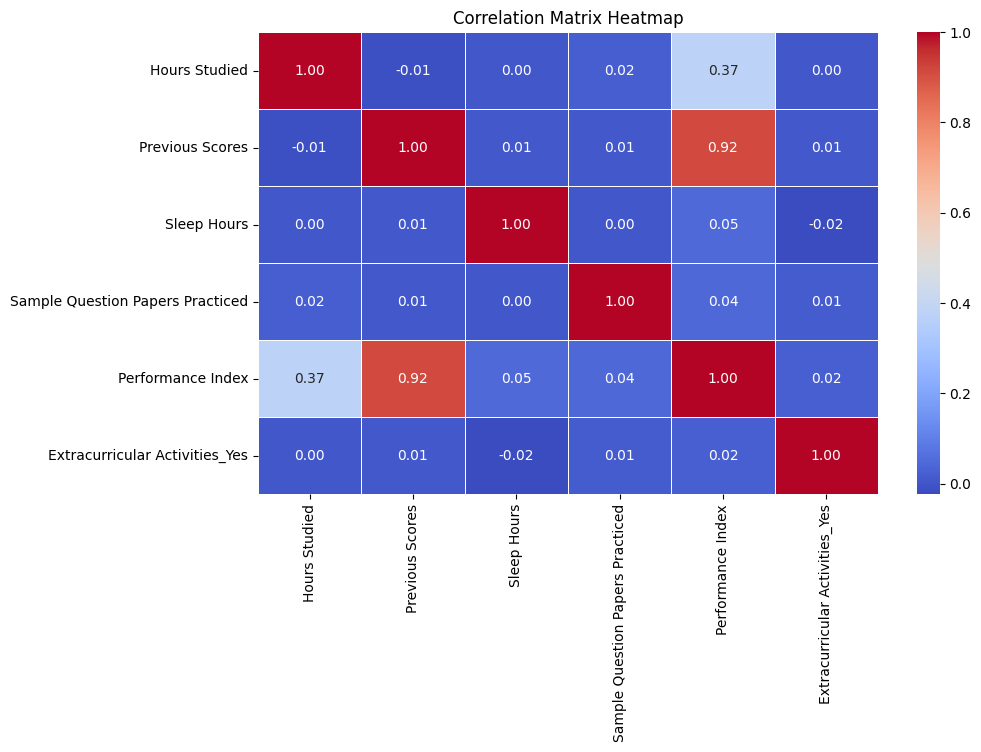

In [25]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix Heatmap")
plt.show()

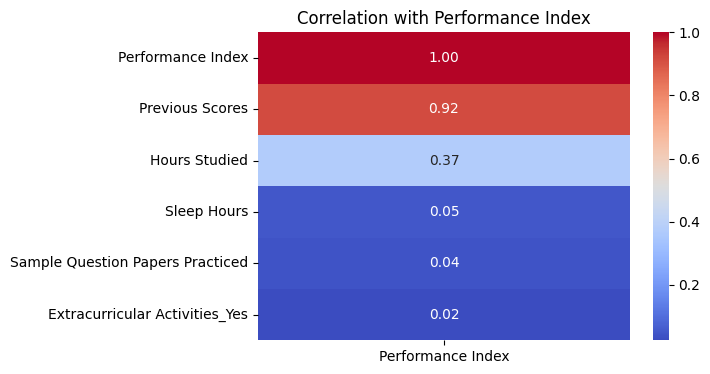

Performance Index                   1.000000
Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Extracurricular Activities_Yes      0.024525
Name: Performance Index, dtype: float64


In [26]:
target_corr = corr["Performance Index"].sort_values(ascending=False)

plt.figure(figsize=(6, 4))
sns.heatmap(
    target_corr.to_frame(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation with Performance Index")
plt.show()

print(target_corr)

In [27]:
threshold = 0.8

high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            col1 = corr.columns[i]
            col2 = corr.columns[j]
            val = corr.iloc[i, j]
            high_corr_pairs.append((col1, col2, val))

print("High Correlation Pairs (>|0.8|):")
for pair in high_corr_pairs:
    print(pair)

High Correlation Pairs (>|0.8|):
('Performance Index', 'Previous Scores', np.float64(0.9151891412264554))


## Chi square

In [28]:
# Contoh: ubah jadi 3 kategori (low, medium, high)
df['Performance Category'] = pd.qcut(
    df['Performance Index'],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [29]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

In [30]:
X = df.drop(columns=["Performance Index", "Performance Category"])
y = df["Performance Category"]

In [31]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [32]:
X = X.apply(lambda x: x - x.min())

In [33]:
chi_scores, p_values = chi2(X, y_encoded)

chi_result = pd.DataFrame({
    "Feature": X.columns,
    "Chi2 Score": chi_scores,
    "p-value": p_values
}).sort_values(by="Chi2 Score", ascending=False)

print(chi_result)

                            Feature    Chi2 Score        p-value
1                   Previous Scores  78135.146188   0.000000e+00
0                     Hours Studied   1372.781278  8.022932e-299
3  Sample Question Papers Practiced     24.763580   4.194275e-06
2                       Sleep Hours     12.724877   1.725154e-03
4    Extracurricular Activities_Yes      1.661623   4.356956e-01


In [34]:
df.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_Yes,Performance Category
0,7,99,9,1,91,1,High
1,4,82,4,2,65,0,Medium
2,8,51,7,2,45,1,Low
3,5,52,5,2,36,1,Low
4,7,75,8,5,66,0,High


# Feature Extraction

## PCA

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [36]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

ValueError: could not convert string to float: 'High'

In [ ]:
pca = PCA()
principal_components = pca.fit_transform(df_scaled)

pc_df = pd.DataFrame(data=principal_components, 
                     columns=[f'PC{i+1}' for i in range(len(df.columns))])

In [ ]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained Variance Ratio:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

print(f"\nCumulative Variance:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"PC1-PC{i+1}: {cum_var:.4f} ({cum_var*100:.2f}%)")

Explained Variance Ratio:
PC1: 0.3313 (33.13%)
PC2: 0.1711 (17.11%)
PC3: 0.1694 (16.94%)
PC4: 0.1655 (16.55%)
PC5: 0.1617 (16.17%)
PC6: 0.0009 (0.09%)

Cumulative Variance:
PC1-PC1: 0.3313 (33.13%)
PC1-PC2: 0.5025 (50.25%)
PC1-PC3: 0.6718 (67.18%)
PC1-PC4: 0.8373 (83.73%)
PC1-PC5: 0.9991 (99.91%)
PC1-PC6: 1.0000 (100.00%)


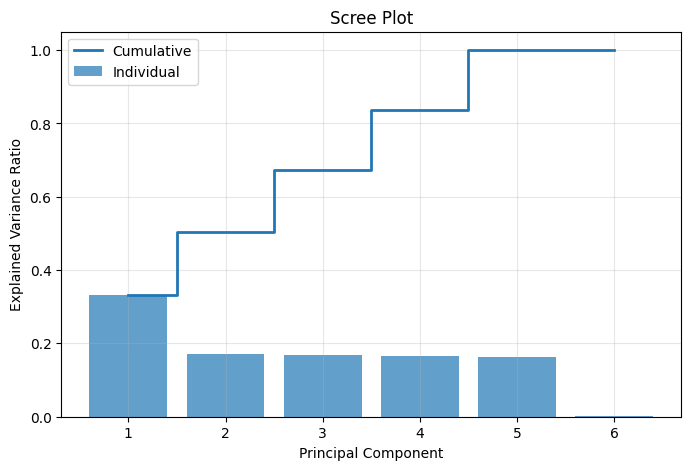

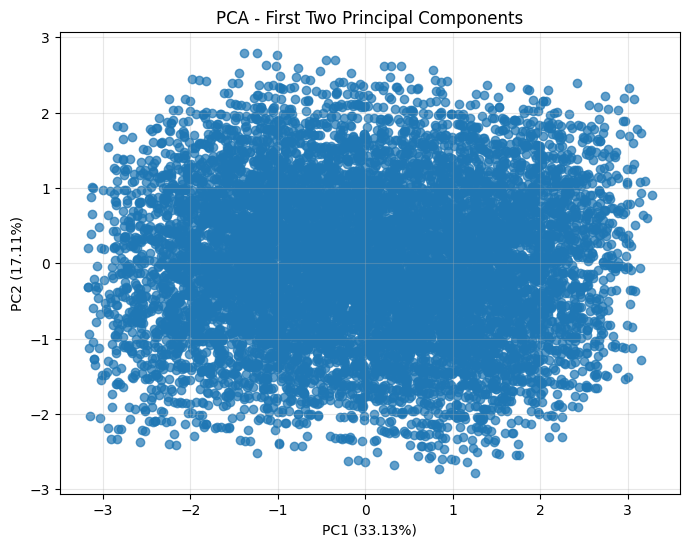

In [ ]:
# Plot scree plot
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance)+1), explained_variance, 
        alpha=0.7, label='Individual')
plt.step(range(1, len(cumulative_variance)+1), cumulative_variance, 
         where='mid', label='Cumulative', linewidth=2)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot PCA 2D
plt.figure(figsize=(8, 6))
plt.scatter(pc_df['PC1'], pc_df['PC2'], alpha=0.7)
plt.xlabel(f'PC1 ({explained_variance[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.2f}%)')
plt.title('PCA - First Two Principal Components')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Loading factors
loading_factors = pd.DataFrame(pca.components_.T, 
                                columns=[f'PC{i+1}' for i in range(len(df.columns))],
                                index=df.columns)
print("\nLoading Factors:")
print(loading_factors)


Loading Factors:
                                       PC1       PC2       PC3       PC4  \
Hours Studied                     0.260536  0.311512  0.660667 -0.554439   
Previous Scores                   0.653427 -0.135405 -0.306564  0.167947   
Sleep Hours                       0.038344 -0.540167  0.442759  0.395436   
Sample Question Papers Practiced  0.041303  0.396139  0.442902  0.680507   
Performance Index                 0.708105 -0.005693 -0.000661 -0.019176   
Extracurricular Activities_Yes    0.023778  0.660217 -0.278100  0.211102   

                                       PC5       PC6  
Hours Studied                     0.129176 -0.272967  
Previous Scores                  -0.081593 -0.652574  
Sleep Hours                       0.594507 -0.030085  
Sample Question Papers Practiced -0.426260 -0.020472  
Performance Index                -0.001878  0.705821  
Extracurricular Activities_Yes    0.664468 -0.011287  


## LDA

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [38]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

lda_df = pd.DataFrame(data=X_lda, columns=['LD1', 'LD2'])
lda_df['Target'] = y.values

In [39]:
explained_variance = lda.explained_variance_ratio_
print("Explained Variance Ratio:")
for i, var in enumerate(explained_variance):
    print(f"LD{i+1}: {var:.4f} ({var*100:.2f}%)")

coefficients = pd.DataFrame(lda.coef_, 
                           columns=X.columns,
                           index=[f'LD{i+1}' for i in range(lda.coef_.shape[0])])
print("\nDiscriminant Coefficients:")
print(coefficients)

print("\nClass Means in LDA Space:")
print(lda.means_)

Explained Variance Ratio:
LD1: 1.0000 (100.00%)
LD2: 0.0000 (0.00%)

Discriminant Coefficients:
     Hours Studied  Previous Scores  Sleep Hours  \
LD1       2.500458         7.430197     0.228042   
LD2      -2.462110        -7.278134    -0.231815   
LD3       0.028813         0.045983     0.010188   

     Sample Question Papers Practiced  Extracurricular Activities_Yes  
LD1                          0.211209                        0.084357  
LD2                         -0.202648                       -0.079256  
LD3                         -0.003100                       -0.002987  

Class Means in LDA Space:
[[ 0.34623243  1.07948378  0.0362673   0.04775701  0.02396777]
 [-0.35083246 -1.05396168 -0.04392098 -0.04261661 -0.01983295]
 [ 0.01429585  0.00311347  0.00895609 -0.00403396 -0.00364171]]


/tmp/ipykernel_26961/3560587585.py:23: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


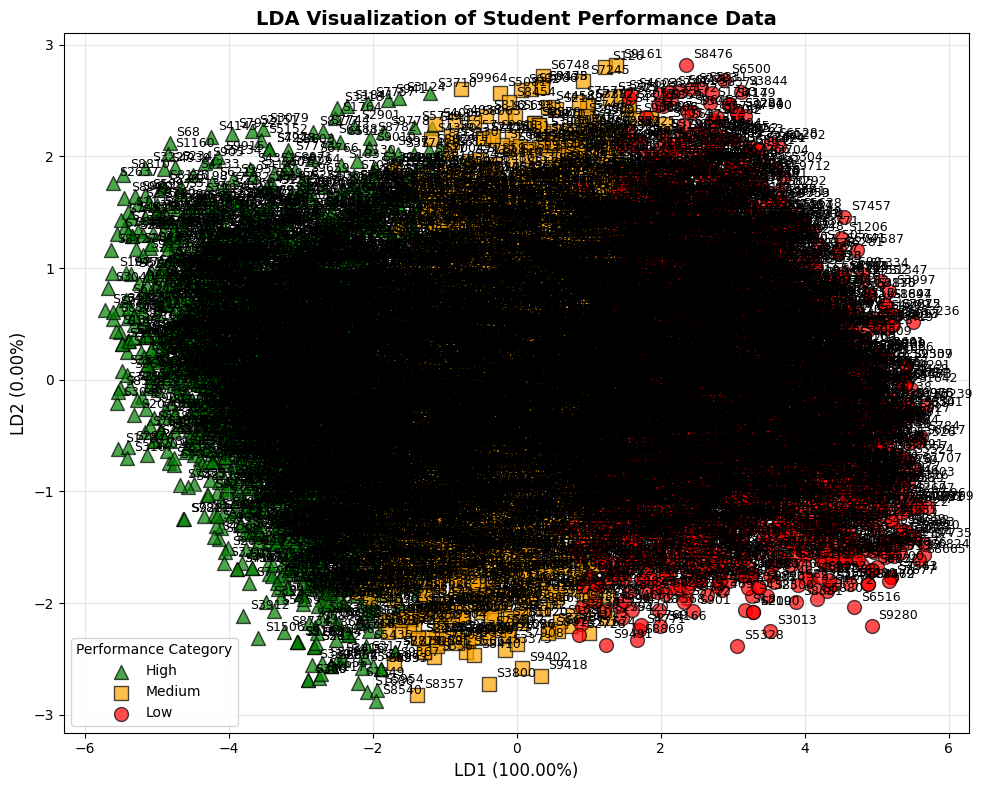

In [40]:
# Plot LDA 2D
plt.figure(figsize=(10, 8))
colors = {'Low': 'red', 'Medium': 'orange', 'High': 'green'}
markers = {'Low': 'o', 'Medium': 's', 'High': '^'}

for target in lda_df['Target'].unique():
    mask = lda_df['Target'] == target
    plt.scatter(lda_df[mask]['LD1'], lda_df[mask]['LD2'], 
                c=colors[target], marker=markers[target], 
                s=100, alpha=0.7, label=target, edgecolors='black')

# Tambahkan label untuk setiap titik
for i, txt in enumerate(lda_df.index):
    plt.annotate(f'S{i}', (lda_df['LD1'][i], lda_df['LD2'][i]), 
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.xlabel(f'LD1 ({explained_variance[0]*100:.2f}%)', fontsize=12)
if len(explained_variance) > 1:
    plt.ylabel(f'LD2 ({explained_variance[1]*100:.2f}%)', fontsize=12)
plt.title('LDA Visualization of Student Performance Data', fontsize=14, fontweight='bold')
plt.legend(title='Performance Category')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

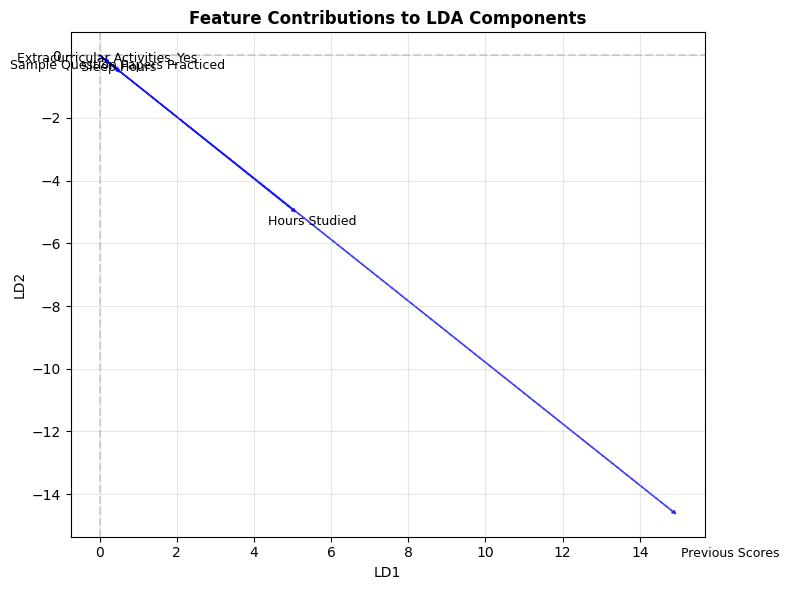

In [ ]:
# Plot kontribusi fitur terhadap LD1 dan LD2
plt.figure(figsize=(8, 6))
for feat in X.columns:
    plt.arrow(0, 0, coefficients.loc['LD1', feat]*2, coefficients.loc['LD2', feat]*2, 
              head_width=0.1, head_length=0.1, fc='blue', ec='blue', alpha=0.7)
    plt.text(coefficients.loc['LD1', feat]*2.2, coefficients.loc['LD2', feat]*2.2, 
             feat, fontsize=9, ha='center')

plt.axhline(0, color='gray', linestyle='--', alpha=0.3)
plt.axvline(0, color='gray', linestyle='--', alpha=0.3)
plt.xlabel('LD1', fontsize=10)
plt.ylabel('LD2', fontsize=10)
plt.title('Feature Contributions to LDA Components', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()